In [1]:
import pandas as pd
import numpy as np

from pathlib import Path


DATA_PATH = Path(
    "../data/processed/renewable_forecasting_dataset.csv"
)


df = pd.read_csv(
    DATA_PATH,
    parse_dates=["datetime"]
)


df.head()

,temperature_2m,relative_humidity_2m,pressure_msl,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,shortwave_radiation,direct_radiation,sunshine_duration,country,datetime,solar_mwh,wind_onshore_mwh,wind_offshore_mwh,wind_total_mwh
0,2.2,95,1033.0,12.0,286,21.6,4,0.0,0.0,0.0,Germany,2020-01-01 00:00:00,0.0,5874.75,1169.25,7044.00
1,1.6,96,1033.3,11.4,283,19.8,2,0.0,0.0,0.0,Germany,2020-01-01 01:00:00,0.0,5764.75,1665.50,7430.25
2,2.1,94,1033.6,10.3,282,19.4,3,0.0,0.0,0.0,Germany,2020-01-01 02:00:00,0.0,5482.50,2062.25,7544.75
3,1.8,95,1033.3,11.2,270,18.7,12,0.0,0.0,0.0,Germany,2020-01-01 03:00:00,0.0,5457.00,2292.00,7749.00
4,1.2,96,1033.6,10.1,276,18.7,3,0.0,0.0,0.0,Germany,2020-01-01 04:00:00,0.0,5566.75,2159.50,7726.25


In [2]:
### SORT AND DATETIME INDEX
df = (
    df
    .sort_values("datetime")
    .reset_index(drop=True)
)


df.head()

,temperature_2m,relative_humidity_2m,pressure_msl,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,shortwave_radiation,direct_radiation,sunshine_duration,country,datetime,solar_mwh,wind_onshore_mwh,wind_offshore_mwh,wind_total_mwh
0,2.2,95,1033.0,12.0,286,21.6,4,0.0,0.0,0.0,Germany,2020-01-01 00:00:00,0.0,5874.75,1169.25,7044.00
1,1.6,96,1033.3,11.4,283,19.8,2,0.0,0.0,0.0,Germany,2020-01-01 01:00:00,0.0,5764.75,1665.50,7430.25
2,2.1,94,1033.6,10.3,282,19.4,3,0.0,0.0,0.0,Germany,2020-01-01 02:00:00,0.0,5482.50,2062.25,7544.75
3,1.8,95,1033.3,11.2,270,18.7,12,0.0,0.0,0.0,Germany,2020-01-01 03:00:00,0.0,5457.00,2292.00,7749.00
4,1.2,96,1033.6,10.1,276,18.7,3,0.0,0.0,0.0,Germany,2020-01-01 04:00:00,0.0,5566.75,2159.50,7726.25


In [6]:
### CALENDAR FEATURES
df["hour"] = df["datetime"].dt.hour

df["day_of_week"] = (
    df["datetime"]
    .dt.dayofweek
)

df["month"] = (
    df["datetime"]
    .dt.month
)

df["day_of_year"] = (
    df["datetime"]
    .dt.dayofyear
)

df["year"] = (
    df["datetime"]
    .dt.year
)

df["day_of_month"] = (
    df["datetime"]
    .dt.day
)

In [8]:
df[
[
"datetime",
"hour",
"day_of_week",
"month",
"day_of_year",
"year"
]
].head()

,datetime,hour,day_of_week,month,day_of_year,year
0,2020-01-01 00:00:00,0,2,1,1,2020
1,2020-01-01 01:00:00,1,2,1,1,2020
2,2020-01-01 02:00:00,2,2,1,1,2020
3,2020-01-01 03:00:00,3,2,1,1,2020
4,2020-01-01 04:00:00,4,2,1,1,2020


In [7]:
#### CYCLIC FEATURES
import numpy as np


# Hour cyclic encoding
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)


# Month cyclic encoding
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

In [9]:
df[
[
    "datetime",
    "hour",
    "hour_sin",
    "hour_cos",
    "month",
    "month_sin",
    "month_cos"
]
].head(24)

,datetime,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,2020-01-01 00:00:00,0,0.000000e+00,1.000000e+00,1,0.5,0.866025
1,2020-01-01 01:00:00,1,2.588190e-01,9.659258e-01,1,0.5,0.866025
2,2020-01-01 02:00:00,2,5.000000e-01,8.660254e-01,1,0.5,0.866025
3,2020-01-01 03:00:00,3,7.071068e-01,7.071068e-01,1,0.5,0.866025
4,2020-01-01 04:00:00,4,8.660254e-01,5.000000e-01,1,0.5,0.866025
5,2020-01-01 05:00:00,5,9.659258e-01,2.588190e-01,1,0.5,0.866025
6,2020-01-01 06:00:00,6,1.000000e+00,6.123234e-17,1,0.5,0.866025
7,2020-01-01 07:00:00,7,9.659258e-01,-2.588190e-01,1,0.5,0.866025
8,2020-01-01 08:00:00,8,8.660254e-01,-5.000000e-01,1,0.5,0.866025
9,2020-01-01 09:00:00,9,7.071068e-01,-7.071068e-01,1,0.5,0.866025


In [10]:
### SOLAR LAG FEATURES

solar_lags = [
    1,
    2,
    3,
    24,
    48,
    168
]

for lag in solar_lags:
    df[f"solar_lag_{lag}"] = (
        df["solar_mwh"]
        .shift(lag)
    )


### WIND LAG FEATURES

wind_lags = [
    1,
    2,
    3,
    24,
    48,
    168
]

for lag in wind_lags:
    df[f"wind_lag_{lag}"] = (
        df["wind_total_mwh"]
        .shift(lag)
    )

In [11]:
df.filter(like="lag").columns

Index(['solar_lag_1', 'solar_lag_2', 'solar_lag_3', 'solar_lag_24',
       'solar_lag_48', 'solar_lag_168', 'wind_lag_1', 'wind_lag_2',
       'wind_lag_3', 'wind_lag_24', 'wind_lag_48', 'wind_lag_168'],
      dtype='str')

In [12]:
df[
[
"datetime",
"solar_mwh",
"solar_lag_1",
"solar_lag_24",
"solar_lag_168",
"wind_total_mwh",
"wind_lag_1",
"wind_lag_24",
"wind_lag_168"
]
].iloc[160:175]

,datetime,solar_mwh,solar_lag_1,solar_lag_24,solar_lag_168,wind_total_mwh,wind_lag_1,wind_lag_24,wind_lag_168
160,2020-01-07 16:00:00,1.00,80.75,1.00,NaN,21015.50,18271.25,16699.25,NaN
161,2020-01-07 17:00:00,0.00,1.00,0.25,NaN,23321.25,21015.50,18253.25,NaN
162,2020-01-07 18:00:00,0.00,0.00,0.00,NaN,25142.00,23321.25,19307.50,NaN
163,2020-01-07 19:00:00,0.00,0.00,0.00,NaN,26793.00,25142.00,20464.75,NaN
164,2020-01-07 20:00:00,0.00,0.00,0.00,NaN,27831.75,26793.00,21154.00,NaN
165,2020-01-07 21:00:00,0.00,0.00,0.00,NaN,27938.25,27831.75,21452.25,NaN
166,2020-01-07 22:00:00,0.00,0.00,0.00,NaN,28929.00,27938.25,21876.50,NaN
167,2020-01-07 23:00:00,0.00,0.00,0.00,NaN,30038.25,28929.00,22240.00,NaN
168,2020-01-08 00:00:00,0.00,0.00,0.00,0.00,30934.50,30038.25,21684.00,7044.00
169,2020-01-08 01:00:00,0.00,0.00,0.00,0.00,31490.75,30934.50,21344.50,7430.25


In [13]:
### ROLLING MEAN FEATURES

windows = [
    3,     # τελευταίες 3 ώρες
    6,     # τελευταίες 6 ώρες
    24,    # τελευταία ημέρα
    168    # τελευταία εβδομάδα
]


for window in windows:

    df[f"solar_roll_mean_{window}"] = (
        df["solar_mwh"]
        .shift(1)
        .rolling(window)
        .mean()
    )


    df[f"wind_roll_mean_{window}"] = (
        df["wind_total_mwh"]
        .shift(1)
        .rolling(window)
        .mean()
    )

In [14]:
### ROLLING STD FEATURES

for window in windows:

    df[f"solar_roll_std_{window}"] = (
        df["solar_mwh"]
        .shift(1)
        .rolling(window)
        .std()
    )


    df[f"wind_roll_std_{window}"] = (
        df["wind_total_mwh"]
        .shift(1)
        .rolling(window)
        .std()
    )

In [15]:
df.filter(like="roll").columns

Index(['solar_roll_mean_3', 'wind_roll_mean_3', 'solar_roll_mean_6',
       'wind_roll_mean_6', 'solar_roll_mean_24', 'wind_roll_mean_24',
       'solar_roll_mean_168', 'wind_roll_mean_168', 'solar_roll_std_3',
       'wind_roll_std_3', 'solar_roll_std_6', 'wind_roll_std_6',
       'solar_roll_std_24', 'wind_roll_std_24', 'solar_roll_std_168',
       'wind_roll_std_168'],
      dtype='str')

In [16]:
df.shape

(52608, 54)

In [17]:
df.isna().sum().sort_values(ascending=False).head(20)

wind_roll_std_168      168
solar_roll_std_168     168
solar_roll_mean_168    168
wind_roll_mean_168     168
solar_lag_168          168
wind_lag_168           168
wind_lag_48             48
solar_lag_48            48
wind_lag_24             24
solar_lag_24            24
wind_roll_std_24        24
solar_roll_std_24       24
solar_roll_mean_24      24
wind_roll_mean_24       24
solar_roll_std_6         6
wind_roll_std_6          6
solar_roll_mean_6        6
wind_roll_mean_6         6
wind_lag_3               3
solar_lag_3              3
dtype: int64

In [18]:
df = df.dropna().reset_index(drop=True)

In [19]:
df.shape

(52440, 54)

In [21]:
df["renewable_total_mwh"] = (
    df["solar_mwh"]
    +
    df["wind_total_mwh"]
)

In [22]:
df[
[
    "datetime",
    "solar_mwh",
    "wind_total_mwh",
    "renewable_total_mwh"
]
].head()

,datetime,solar_mwh,wind_total_mwh,renewable_total_mwh
0,2020-01-08 00:00:00,0.0,30934.50,30934.50
1,2020-01-08 01:00:00,0.0,31490.75,31490.75
2,2020-01-08 02:00:00,0.0,31423.50,31423.50
3,2020-01-08 03:00:00,0.0,31030.00,31030.00
4,2020-01-08 04:00:00,0.0,31005.00,31005.00


Business Insight:

Renewable generation forecasting is mainly driven by short-term weather conditions and temporal patterns. Solar generation follows strong daily and seasonal cycles, while wind generation depends more on atmospheric variability. Combining meteorological variables with historical generation behaviour improves prediction accuracy and supports grid planning and renewable integration.

In [24]:
df.to_csv(
    "../data/processed/renewable_forecasting_dataset.csv",
    index=False
)

In [78]:
train = df[
    df["datetime"] < "2025-01-01"
].copy()


test = df[
    df["datetime"] >= "2025-01-01"
].copy()

In [79]:
print("Train:")
print(train["datetime"].min())
print(train["datetime"].max())

print()

print("Test:")
print(test["datetime"].min())
print(test["datetime"].max())

Train:
2020-01-08 00:00:00
2024-12-31 23:00:00

Test:
2025-01-01 00:00:00
2025-12-31 23:00:00


In [80]:
target = "renewable_total_mwh"



In [81]:
drop_columns = [
    "datetime",
    "country",
    "solar_mwh",
    "wind_onshore_mwh",
    "wind_offshore_mwh",
    "wind_total_mwh",
    target
]

In [82]:
X_train = train.drop(columns=drop_columns)

X_test = test.drop(columns=drop_columns)

y_train = train[target]

y_test = test[target]

In [83]:
print(X_train.shape)

print(X_train.columns.tolist())

(43680, 48)
['temperature_2m', 'relative_humidity_2m', 'pressure_msl', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'cloud_cover', 'shortwave_radiation', 'direct_radiation', 'sunshine_duration', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'year', 'day_of_month', 'solar_lag_1', 'solar_lag_2', 'solar_lag_3', 'solar_lag_24', 'solar_lag_48', 'solar_lag_168', 'wind_lag_1', 'wind_lag_2', 'wind_lag_3', 'wind_lag_24', 'wind_lag_48', 'wind_lag_168', 'solar_roll_mean_3', 'wind_roll_mean_3', 'solar_roll_mean_6', 'wind_roll_mean_6', 'solar_roll_mean_24', 'wind_roll_mean_24', 'solar_roll_mean_168', 'wind_roll_mean_168', 'solar_roll_std_3', 'wind_roll_std_3', 'solar_roll_std_6', 'wind_roll_std_6', 'solar_roll_std_24', 'wind_roll_std_24', 'solar_roll_std_168', 'wind_roll_std_168']


In [84]:
######### Baseline Model
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)

In [85]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    pred_baseline
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_baseline
    )
)

r2 = r2_score(
    y_test,
    pred_baseline
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 11925.31
RMSE: 14460.12
R²  : -0.0362


In [87]:
###### RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


In [88]:
pred_rf = rf.predict(X_test)

In [89]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R²  :", r2_score(y_test, pred_rf))

MAE : 1086.5207199010601
RMSE: 1594.1347465543176
R²  : 0.9874067435280717


In [90]:
importance = (
    pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    )
    .sort_values(
        ascending=False
    )
)

importance.head(20)

wind_lag_1             0.528240
solar_lag_24           0.337887
solar_lag_1            0.082671
solar_roll_std_6       0.011913
solar_lag_48           0.008837
solar_roll_std_3       0.004294
hour_sin               0.003403
hour                   0.003356
wind_roll_mean_6       0.003122
wind_roll_mean_3       0.002698
wind_lag_2             0.001479
solar_lag_168          0.001375
wind_lag_3             0.001309
solar_roll_mean_24     0.000856
wind_roll_std_3        0.000664
solar_roll_std_24      0.000506
solar_roll_mean_6      0.000502
solar_lag_3            0.000394
pressure_msl           0.000346
solar_roll_mean_168    0.000340
dtype: float64

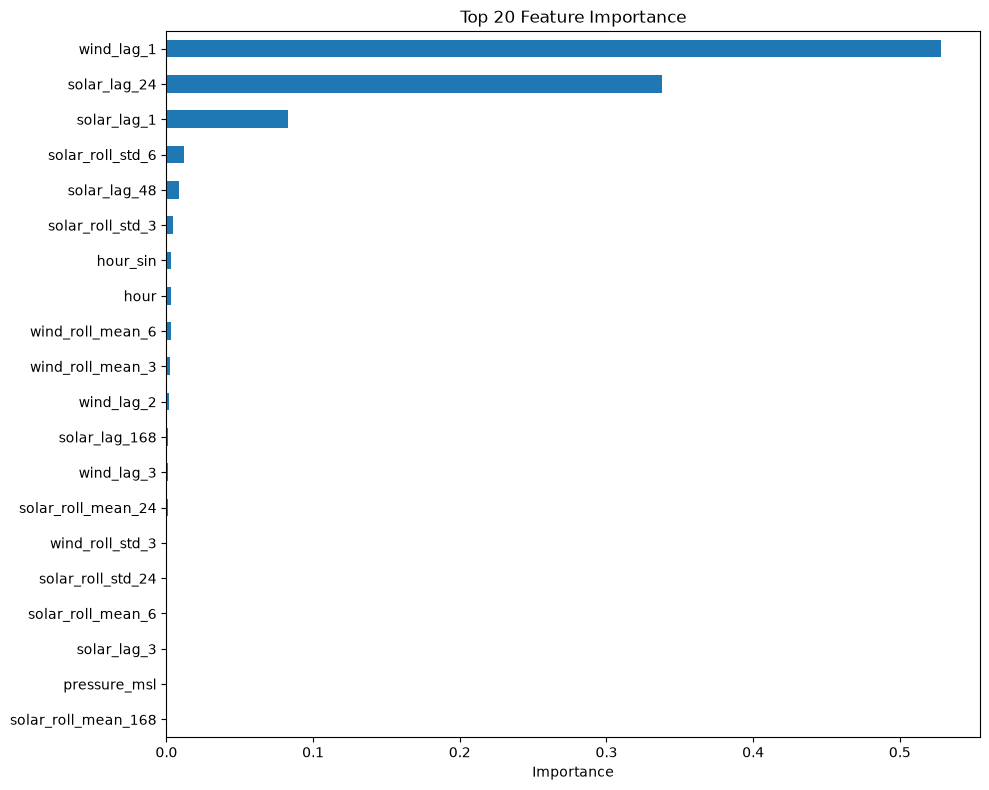

In [91]:
import matplotlib.pyplot as plt

importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [92]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_rf
})

results.head()

,Actual,Predicted
43680,35925.00,36315.276423
43681,36390.00,36124.770765
43682,34569.75,36451.321560
43683,34450.50,33591.906914
43684,34743.25,33785.750176


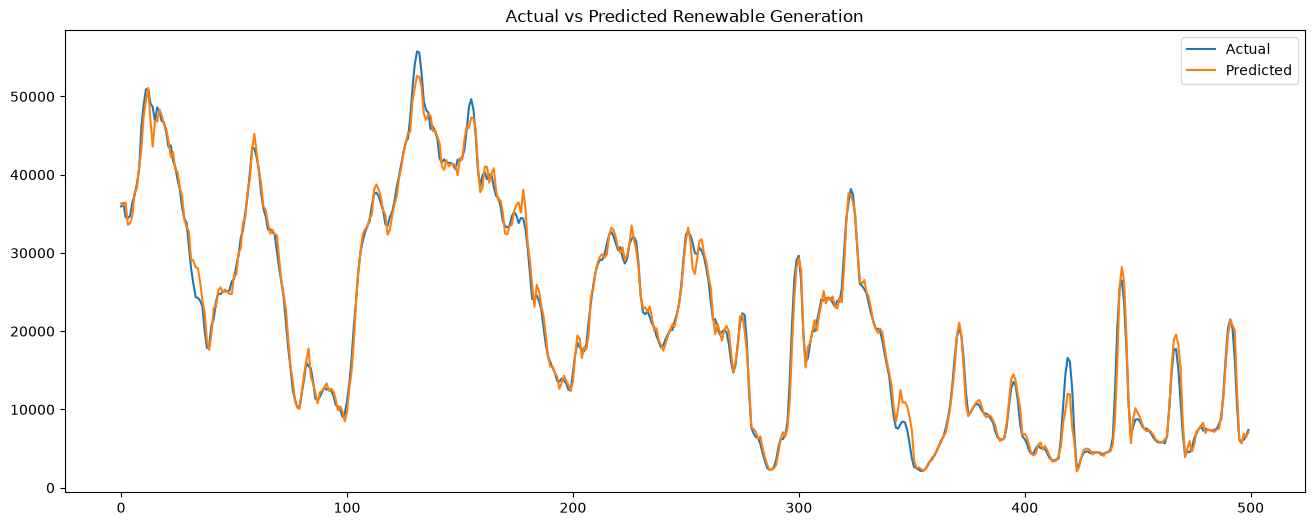

In [93]:
plt.figure(figsize=(16,6))

plt.plot(
    results["Actual"].values[:500],
    label="Actual"
)

plt.plot(
    results["Predicted"].values[:500],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Renewable Generation")

plt.show()

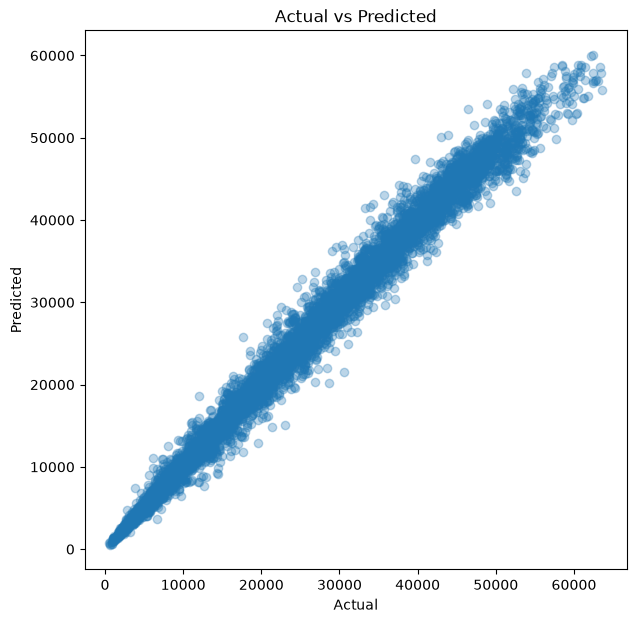

In [94]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    pred_rf,
    alpha=0.3
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

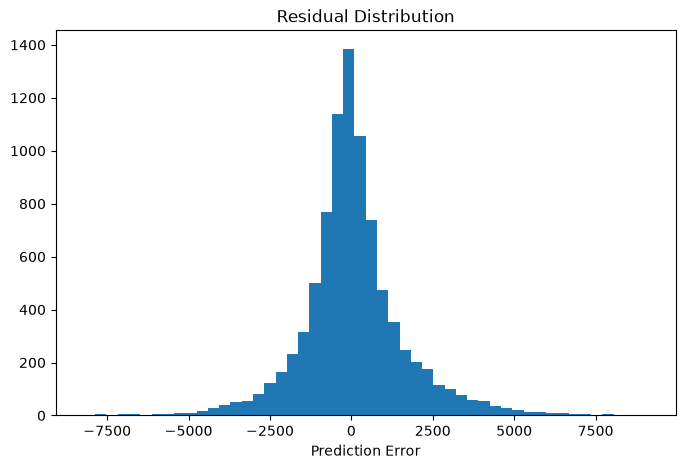

In [97]:
residuals = y_test - pred_rf

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=50
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

In [99]:
print(residuals.describe())

count    8760.000000
mean       53.711746
std      1593.320571
min     -8213.712477
25%      -691.995307
50%       -49.548940
75%       680.394117
max      9095.760758
Name: renewable_total_mwh, dtype: float64


In [100]:
error_analysis = pd.DataFrame({
    "datetime": test["datetime"],
    "actual": y_test,
    "prediction": pred_rf,
    "error": residuals
})

error_analysis["abs_error"] = (
    error_analysis["error"]
    .abs()
)

error_analysis.sort_values(
    "abs_error",
    ascending=False
).head(10)

,datetime,actual,prediction,error,abs_error
46280,2025-04-19 08:00:00,30583.00,21487.239242,9095.760758,9095.760758
47772,2025-06-20 12:00:00,52594.50,43585.395000,9009.105000,9009.105000
46286,2025-04-19 14:00:00,28693.25,20181.797500,8511.452500,8511.452500
47771,2025-06-20 11:00:00,53445.00,45099.335000,8345.665000,8345.665000
47608,2025-06-13 16:00:00,33296.25,41509.962477,-8213.712477,8213.712477
48160,2025-07-06 16:00:00,17591.43,25774.155833,-8182.725833,8182.725833
46279,2025-04-19 07:00:00,23082.25,15074.934104,8007.315896,8007.315896
47770,2025-06-20 10:00:00,53683.75,45760.531667,7923.218333,7923.218333
50793,2025-10-24 09:00:00,63644.73,55759.149167,7885.580833,7885.580833
47604,2025-06-13 12:00:00,57644.00,49840.012500,7803.987500,7803.987500


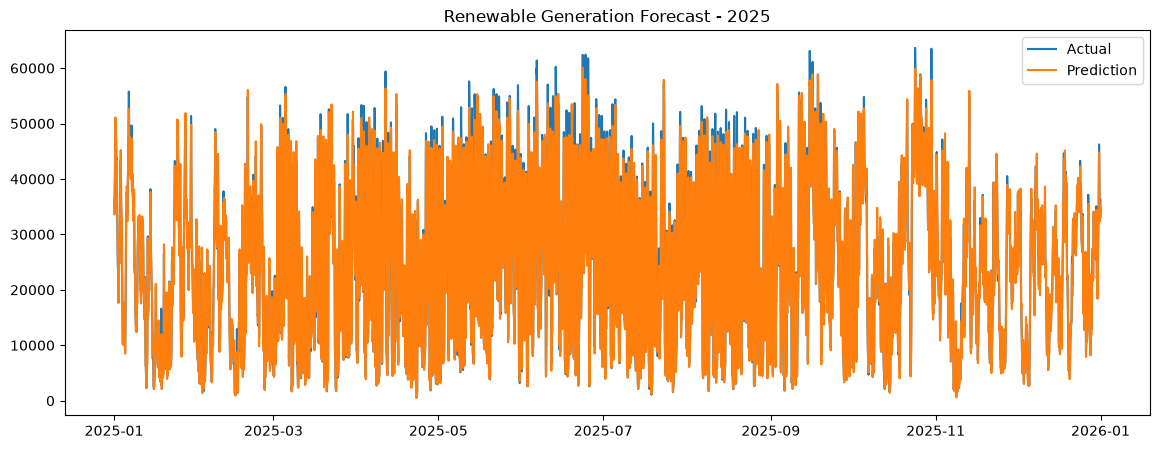

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    error_analysis["datetime"],
    error_analysis["actual"],
    label="Actual"
)

plt.plot(
    error_analysis["datetime"],
    error_analysis["prediction"],
    label="Prediction"
)

plt.legend()
plt.title("Renewable Generation Forecast - 2025")
plt.show()

The model successfully captures the main renewable generation patterns, achieving high predictive accuracy (R² = 0.987). Forecast deviations are concentrated around rapid generation ramps, mainly caused by sudden solar output changes. This indicates that short-term renewable forecasting is strongly influenced by weather-driven variability, especially solar radiation fluctuations and wind persistence.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# split
train = df[
    df["datetime"] < "2025-01-01"
].copy()

test = df[
    df["datetime"] >= "2025-01-01"
].copy()


target = "renewable_total_mwh"


# remove non-features
drop_cols = [
    "datetime",
    "country",
    "renewable_total_mwh",
    "solar_mwh",
    "wind_onshore_mwh",
    "wind_offshore_mwh",
    "wind_total_mwh"
]



X_train = train.drop(
    columns=drop_cols,
    errors="ignore"
)

y_train = train[target]


X_test = test.drop(
    columns=drop_cols,
    errors="ignore"
)

y_test = test[target]


print(X_train.shape)
print(X_test.shape)


# model
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


# train
xgb.fit(
    X_train,
    y_train
)


# prediction
pred_xgb = xgb.predict(
    X_test
)


# metrics
mae = mean_absolute_error(
    y_test,
    pred_xgb
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_xgb
    )
)

r2 = r2_score(
    y_test,
    pred_xgb
)


print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

(43680, 52)
(8760, 52)
MAE : 267.72034766516833
RMSE: 669.7414648162936
R²  : 0.9977771898687015


In [106]:
importance_xgb = (
    pd.Series(
        xgb.feature_importances_,
        index=X_train.columns
    )
    .sort_values(
        ascending=False
    )
)

importance_xgb.head(20)

wind_onshore_mwh     0.421364
solar_mwh            0.193338
wind_lag_1           0.111858
wind_total_mwh       0.108855
solar_lag_24         0.095861
solar_lag_1          0.038714
hour                 0.007753
solar_lag_48         0.003980
solar_roll_mean_3    0.002892
solar_roll_std_6     0.002678
wind_roll_mean_6     0.002624
solar_roll_std_3     0.002244
solar_roll_std_24    0.001654
wind_roll_mean_3     0.001353
solar_roll_mean_6    0.000978
wind_lag_2           0.000772
wind_lag_3           0.000411
solar_lag_3          0.000375
solar_lag_168        0.000351
wind_offshore_mwh    0.000251
dtype: float32

In [107]:
residuals_xgb = y_test - pred_xgb

residuals_xgb.describe()

count     8760.000000
mean        91.278585
std        663.530036
min      -2518.421875
25%        -80.480938
50%          0.753975
75%         99.216309
max      10570.285156
Name: renewable_total_mwh, dtype: float64

The gradient boosting model significantly improved renewable generation forecasting accuracy compared with the Random Forest baseline. The model reduced average forecasting error to approximately 268 MWh while explaining 99.8% of the observed variability in renewable generation. Remaining errors are mainly associated with extreme generation ramps caused by rapidly changing weather conditions.